# Predicting Cancer Type Using TCGA Gene Expression Data

Based off work published by [Divate et al. (2022)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8909043/) and [ISB-CGC example notebook](https://github.com/isb-cgc/Community-Notebooks/blob/master/MachineLearning/How_to_predict_cancer_survival_with_BigQueryML.ipynb)

Using TCGA RNAseq data from ISB_CGC (Table ID: isb-cgc-bq.TCGA_versioned.RNAseq_hg38_gdc_r42)

Repeated methods on TCGA dataset

### Import Dependencies

In [2]:
# GCP Libraries
from google.cloud import bigquery
from google.colab import auth

# Data Analytics
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from scipy import stats

import torch
from torch import optim, nn, utils, Tensor
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import lightning as L
import torchmetrics

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

### Authenticate

In [3]:
auth.authenticate_user()

### Parameters

In [ ]:
google_project = 'project_name' #CHANGE
bq_project = google_project
bq_dataset = 'TCGA_RNAseq'
bq_table = 'TCGA_ML_data'
rnaseq_table = "isb-cgc-bq.TCGA_versioned.RNAseq_hg38_gdc_r42"

In [5]:
client = bigquery.Client(google_project)

## Selecting Data Using SQL Query
Using similar methodology as Divate et al. (2022), I will be using protein-coding gene expression data.
Additionally, as done within the work, I will select genes with $\geq 5$ FPKM in at least 50% of the samples within any cancer type.

Also, rather than averaging FPKM across aliquots from one sample, I will use each aliquot as a separate sample.

### Query
Processes about 60 GB

In [ ]:
sql = ("""
BEGIN
CREATE OR REPLACE TABLE `{bq_project}.{bq_dataset}.{bq_table}` AS

  -- Select data from protein-coding genes and samples
  WITH protein_coding AS (
        SELECT
          (SPLIT(project_short_name,  '-'))[safe_ordinal(2)] AS cancer_type,
          aliquot_barcode,
          fpkm_unstranded,
          Ensembl_gene_id_v
        FROM {rnaseq_table}
        WHERE gene_name IS NOT NULL
          AND gene_type = 'protein_coding'
        ),
  -- Select genes that pass threshold of >= 5 FPKM in at least 50% of samples within any cancer_type
  -- Remove samples with PAR_Y as the Y chromosome is not present in all individuals, which may skew the counts
      threshold AS (
        SELECT
          DISTINCT Ensembl_gene_id_v
        FROM (
          SELECT
            cancer_type,
            Ensembl_gene_id_v,
            COUNT(Ensembl_gene_id_v) as num_samples,
            COUNT(CASE WHEN fpkm_unstranded >= 5.0 THEN 1 END) as num_fpkm_threshold,
          FROM protein_coding
          WHERE CONTAINS_SUBSTR(Ensembl_gene_id_v, 'par_y') = FALSE
          GROUP BY cancer_type, Ensembl_gene_id_v)
        WHERE num_fpkm_threshold / num_samples >= 0.5
      )

  -- Select data from genes that pass the threshold
  SELECT
    cancer_type,
    aliquot_barcode,
    fpkm_unstranded,
    (SPLIT(pc.Ensembl_gene_id_v,  '.'))[safe_ordinal(1)] AS Ensembl_gene_id
  FROM protein_coding AS pc
  INNER JOIN threshold AS t
    ON pc.Ensembl_gene_id_v = t.Ensembl_gene_id_v;
END;
""").format(
  bq_project=bq_project,
  bq_dataset=bq_dataset,
  bq_table=bq_table,
  rnaseq_table=rnaseq_table)

print(sql)

In [7]:
# result = client.query(sql)

* 33 cancer types, 11499 samples, 12555 genes

We want to load all the data (8.18 GB) to be used for the ML model. However, loading this into a dataframe takes up more RAM than available in Colab. Thus, we will be splitting up the samples into multiple tables
```
sql = ("""
  SELECT
    *
  FROM `{bq_project}.{bq_dataset}.{bq_table}`
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()
```

### Importing barcodes and cancer types and splitting them into 4 groups
These groups will be stratified so that there is around the same proportion of cancer types in each group.

First three splits will be used in training.

Last split will be reserved for testing


```
sql = ("""
  SELECT
    DISTINCT aliquot_barcode,
    cancer_type
  FROM `{bq_project}.{bq_dataset}.{bq_table}`
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()
```

```
y = df['cancer_type']
X = df['aliquot_barcode']
X0, X1, y0, y1 = train_test_split(X, y, test_size=0.5, random_state=123, shuffle=True, stratify=y)
X0, X2, y0, y2 = train_test_split(X0, y0, test_size=0.5, random_state=123, shuffle=True, stratify=y0)
X1, X3, y1, y3 = train_test_split(X1, y1, test_size=0.5, random_state=123, shuffle=True, stratify=y1)
```

### Save splits to BigQuery tables

```
X0 = X0.to_frame()
X1 = X1.to_frame()
X2 = X2.to_frame()
X3 = X3.to_frame()
```
```
for i, d in enumerate([X0, X1, X2, X3]):
  job = client.load_table_from_dataframe(
      d, f"{bq_project}.{bq_dataset}.TCGA_sample_split_{i}")
  job.result()
```


# First split



In [6]:
sql = ("""
  SELECT
    cancer_type,
    t.aliquot_barcode,
    fpkm_unstranded,
    Ensembl_gene_id
  FROM `{bq_project}.{bq_dataset}.{bq_table}` as t
  INNER JOIN (
    SELECT
      aliquot_barcode
    FROM `{bq_project}.{bq_dataset}.TCGA_sample_split_0`
  ) as s
  ON t.aliquot_barcode = s.aliquot_barcode
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()

In [41]:
df[['cancer_type', 'aliquot_barcode', 'Ensembl_gene_id']].nunique()

,0
cancer_type,33
aliquot_barcode,2874
Ensembl_gene_id,12555


Split 1:
* 2874 samples

### Pivot DataFrame for FPKM per gene per sample



This is the BQ Query I would use to pivot the table with SQL. However, there is a max of 10,000 columns in BQ, so Pandas DataFrames will be used instead.
```
DECLARE columns STRING;

SET columns = (
  SELECT CONCAT('(', STRING_AGG(FORMAT('%T', Ensembl_gene_id), ','), ')') AS Ensembl_gene_id,
  FROM {threshold}
);

EXECUTE IMMEDIATE FORMAT("""
  SELECT
    *
  FROM  (SELECT aliquot_barcode, cancer_type, Ensembl_gene_id, AVG(fpkm_unstranded) as fpkm_unstranded
        FROM {table}
        GROUP BY aliquot_barcode, cancer_type, Ensembl_gene_id)
  PIVOT
  (
    AVG(fpkm_unstranded)
    FOR Ensembl_gene_id IN %s
  )
""", columns);
```

In [7]:
data = df.pivot(index=['aliquot_barcode', 'cancer_type'], columns='Ensembl_gene_id', values='fpkm_unstranded')

# reset pivot table formatting
data.reset_index(inplace=True)
data.columns.name = None
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2874 entries, 0 to 2873
Columns: 12557 entries, aliquot_barcode to ENSG00000288658
dtypes: float64(12555), object(2)
memory usage: 275.3+ MB
None


,aliquot_barcode,cancer_type,ENSG00000000003,ENSG00000000419,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001461,...,ENSG00000283632,ENSG00000283787,ENSG00000284024,ENSG00000284691,ENSG00000284753,ENSG00000284976,ENSG00000286190,ENSG00000286522,ENSG00000287080,ENSG00000288658
0,TCGA-02-0003-01A-01R-A96R-41,GBM,22.3883,16.0602,2.8233,1.6710,9.0567,7.2661,5.8802,5.7884,...,0.4708,0.1509,4.5667,1.2728,2.1528,6.5290,33.1308,839.1531,414.4843,0.1179
1,TCGA-02-0016-01A-01R-A96R-41,GBM,23.4569,18.3652,5.1026,2.6506,14.8364,3.9977,9.5293,8.0521,...,0.2727,0.3635,4.0494,1.9842,1.2536,7.8853,34.7487,111.8536,84.6995,0.0628
2,TCGA-02-2483-01A-01R-1849-01,GBM,21.3506,40.6403,5.6149,1.8236,11.8432,5.5017,7.2592,1.6423,...,1.4094,0.0524,5.9887,1.6423,3.0547,14.5679,31.2893,1.1344,0.5347,3.8604
3,TCGA-02-2483-01A-01R-A96R-41,GBM,10.1563,17.8118,7.8110,1.9633,8.3347,5.3412,8.9414,2.7887,...,1.5046,0.4073,9.2968,1.3100,3.0304,13.6273,12.4536,2280.5728,1321.5732,0.6748
4,TCGA-04-1361-01A-01R-1565-13,OV,22.8567,30.1383,1.1683,2.4830,17.6592,3.5325,6.9552,2.2252,...,1.2748,0.2100,3.2784,3.0452,15.0584,9.6716,4.6947,1.4551,2.1900,0.1523


### Pre-Process and Transform Data for Machine Learning Input


In [8]:
y = data['cancer_type']
X = data.select_dtypes(include="number")

### Log Transform FPKM Values
As done in Divate et al. (2022), I will log10 transform the values before input into the machine learning model.

In [9]:
X_log = np.log10(X + 1)

Text(0.5, 1.0, 'Log10(x+1) Transformed Data')

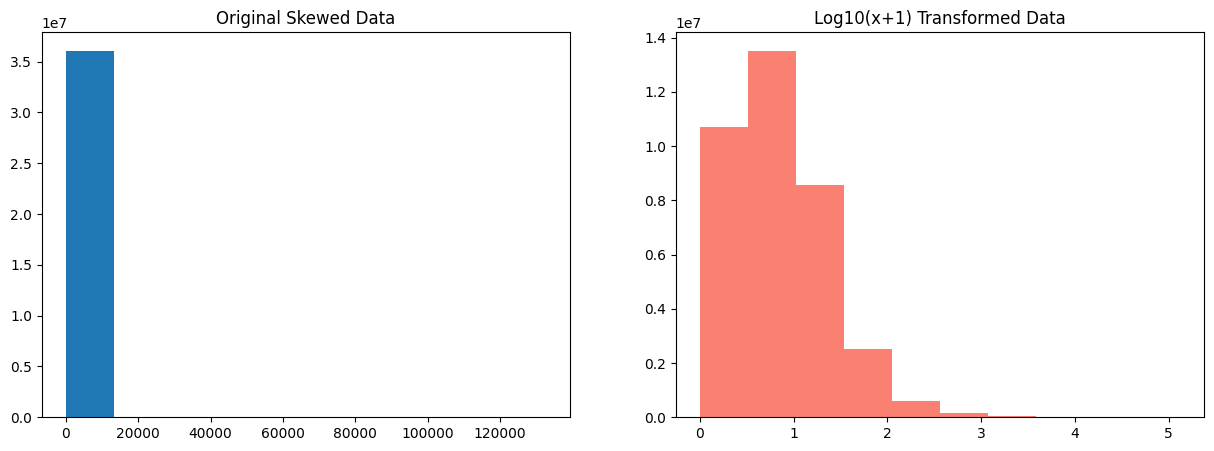

In [13]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(X.values.ravel(), bins=10)
plt.title("Original Skewed Data")

plt.subplot(1, 2, 2)
plt.hist(X_log.values.ravel(), bins=10, color='Salmon')
plt.title("Log10(x+1) Transformed Data")


### Label encode primary sites

In [10]:
le = LabelEncoder()
y = pd.DataFrame(le.fit_transform(y), columns=['cancer_type'])

<Axes: xlabel='cancer_type'>

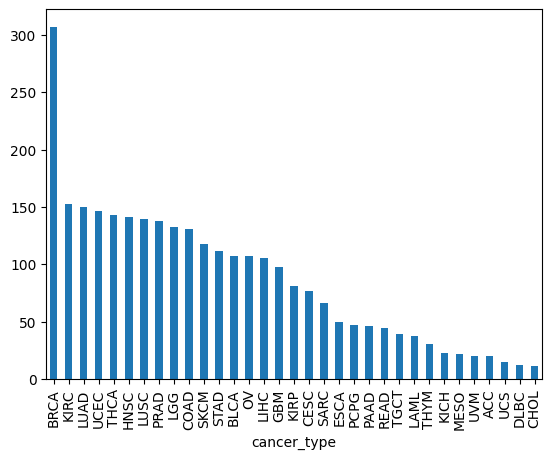

In [15]:
data['cancer_type'].value_counts().plot(kind='bar')

### T-SNE Plot to Observe Clustering

In [16]:
tsne = pd.DataFrame(TSNE(n_components=2, random_state=123).fit_transform(X), columns=['Dim1', 'Dim2'])
tsne_log = pd.DataFrame(TSNE(n_components=2, random_state=123).fit_transform(X_log), columns=['Dim1', 'Dim2'])

In [18]:
C = y['cancer_type'].nunique()  # Number of labels

In [19]:
# define the colormap
cmap = plt.cm.jet
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]
# create the new map
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)

# define the bins and normalize
bounds = np.linspace(0, C, C+1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

Text(0.5, 1.0, 'Log10(x+1) Transformed Data')

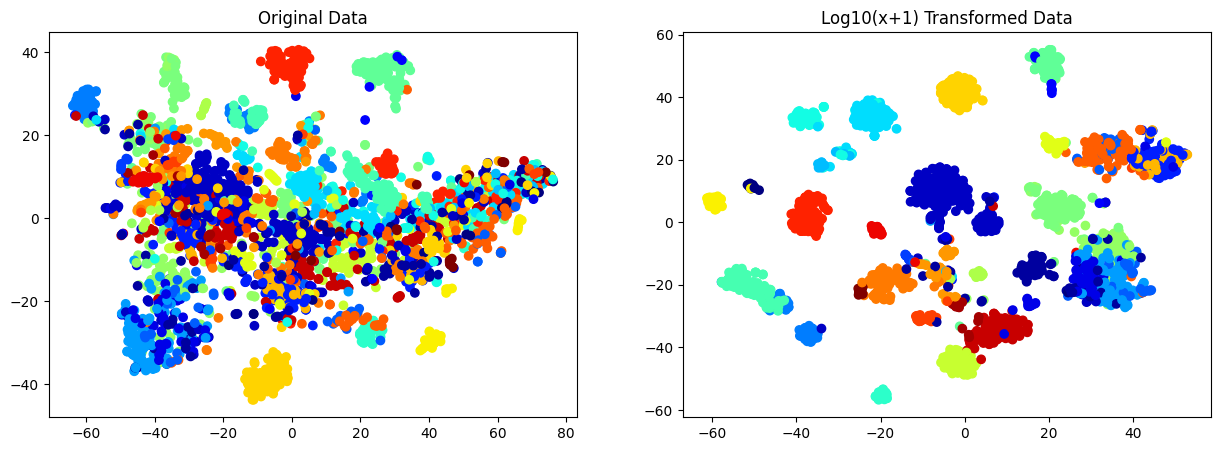

In [20]:
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(x=tsne['Dim1'], y=tsne['Dim2'], c=y['cancer_type'], cmap=cmap, norm=norm)
plt.title("Original Data")

plt.subplot(1, 2, 2)
plt.scatter(x=tsne_log['Dim1'], y=tsne_log['Dim2'], c=y['cancer_type'], cmap=cmap, norm=norm)
plt.title("Log10(x+1) Transformed Data")


### Split data into different sets

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [12]:
# 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X_log, y, test_size=0.2, random_state=123)

In [23]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.flatten())
y_val_tensor = torch.tensor(y_val.values.flatten())

In [24]:
train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)

## Machine Learning Model


The model used is similar to the model discussed in Divate et al. (2022) with implementation in PyTorch and some changes to layers.

In [13]:
C = y['cancer_type'].nunique()  # Number of labels
input_size = X.shape[1]

class NeuralNetwork(L.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, C)
        )

        self.learning_rate = learning_rate
        self.train_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=C)
        self.valid_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=C)

    def forward(self, batch):
        inputs, _ = batch
        return self.model(inputs)

    def training_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.train_acc(output, target)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_accuracy", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.valid_acc(output, target)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_accuracy", self.valid_acc, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.valid_acc(output, target)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_accuracy", self.valid_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


### Custom Logger
For displaying loss curves

In [14]:
import collections
from lightning.pytorch.loggers.logger import Logger, rank_zero_experiment
from lightning.pytorch.utilities import rank_zero_only

class CustomLogger(Logger):
    def __init__(self):
      super().__init__()

      self.history = collections.defaultdict(list)

    @property
    def name(self):
      return "Logger"

    @property
    def version(self):
      return "0.1"

    @rank_zero_only
    def log_hyperparams(self, params):
      # params is an argparse.Namespace
      pass

    @rank_zero_only
    def log_metrics(self, metrics, step):
      for metric_name, metric_value in metrics.items():
        if metric_name != 'epoch':
            self.history[metric_name].append(metric_value)
        else:
            if (not len(self.history['epoch']) or
                not self.history['epoch'][-1] == metric_value) :
                self.history['epoch'].append(metric_value)
            else:
                pass
      return

### Set training parameters

In [15]:
learning_rate = 1e-5
batch_size = 1
epochs = 50
patience = 3
delta = 0.00
val_epochs = 1

### Load data and model

In [16]:
model = NeuralNetwork(learning_rate)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)

### Set up training

In [43]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=delta, patience=patience, mode="min")
checkpoint_callback = ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/',
                                          filename='best')
logger = CustomLogger()

trainer = L.Trainer(max_epochs=epochs,
                    check_val_every_n_epoch=val_epochs,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    logger=logger
                    )

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Training Loop

In [30]:
trainer.fit(model, train_dataloader, val_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential         │  6.6 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.6 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

### Plotting Loss and Accuracy Over Training

In [31]:
# For default logging:
# %reload_ext tensorboard
# %tensorboard --logdir=lightning_logs/

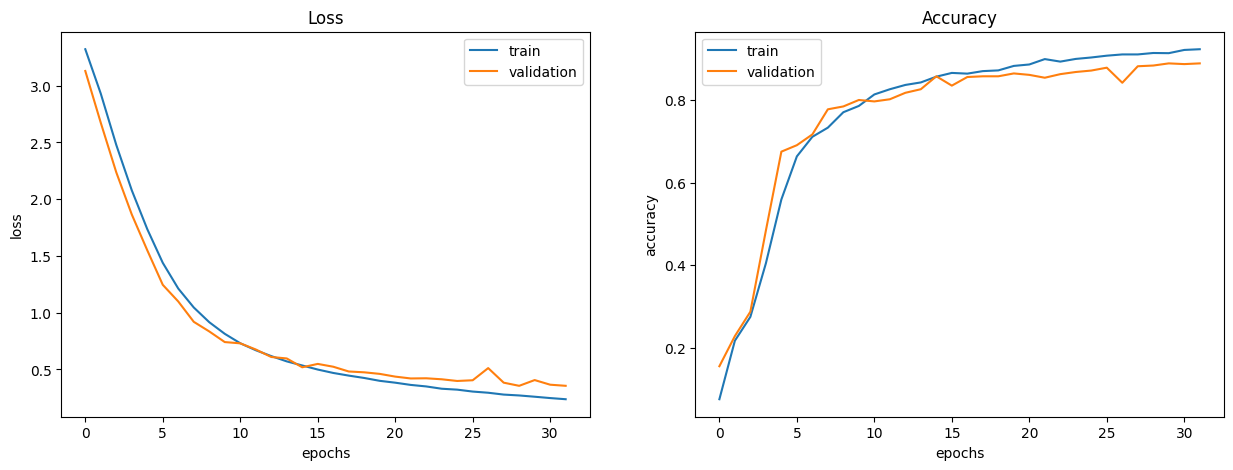

In [32]:
x_axis = logger.history['epoch']
train_loss = logger.history['train_loss']
val_loss = logger.history['val_loss']
train_acc = logger.history['train_accuracy']
val_acc = logger.history['val_accuracy']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(x_axis, train_loss, label='train')
plt.plot(x_axis, val_loss, label='validation')
plt.legend()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_acc, label='train')
plt.plot(x_axis, val_acc, label='validation')
plt.legend()
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title("Accuracy")
plt.show()

## Split 2

In [29]:
import gc
gc.collect()

0

In [20]:
sql = ("""
  SELECT
    cancer_type,
    t.aliquot_barcode,
    fpkm_unstranded,
    Ensembl_gene_id
  FROM `{bq_project}.{bq_dataset}.{bq_table}` as t
  INNER JOIN (
    SELECT
      aliquot_barcode
    FROM `{bq_project}.{bq_dataset}.TCGA_sample_split_1`
  ) as s
  ON t.aliquot_barcode = s.aliquot_barcode
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()
df[['cancer_type', 'aliquot_barcode', 'Ensembl_gene_id']].nunique()

,0
cancer_type,33
aliquot_barcode,2875
Ensembl_gene_id,12555


Split 2:
* 2875 samples

In [21]:
data = df.pivot(index=['aliquot_barcode', 'cancer_type'], columns='Ensembl_gene_id', values='fpkm_unstranded')

# reset pivot table formatting
data.reset_index(inplace=True)
data.columns.name = None

y = data['cancer_type']
X = data.select_dtypes(include="number")

X_log = np.log10(X + 1)
y = pd.DataFrame(le.fit_transform(y), columns=['cancer_type'])

X_val_old = X_val
y_val_old = y_val


In [24]:
# 80% train + prev 20% val, 20% val
X_train, X_val, y_train, y_val = train_test_split(X_log, y, test_size=0.2, random_state=123)
# Use previous validation set as training data
X_train = pd.concat([X_train, X_val_old])
y_train = pd.concat([y_train, y_val_old])

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.flatten())
y_val_tensor = torch.tensor(y_val.values.flatten())

train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)

### Train from checkpoint

In [ ]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=delta, patience=patience, mode="min")
checkpoint_callback = ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/',
                                          filename='best')
logger = CustomLogger()

trainer = L.Trainer(max_epochs=epochs,
                    check_val_every_n_epoch=val_epochs,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    logger=logger
                    )

In [44]:
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
model = NeuralNetwork.load_from_checkpoint('/content/best.ckpt', weights_only=True, learning_rate=learning_rate)
trainer.fit(model, train_dataloader, val_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential         │  6.6 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.6 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

### Split 2 Plotting

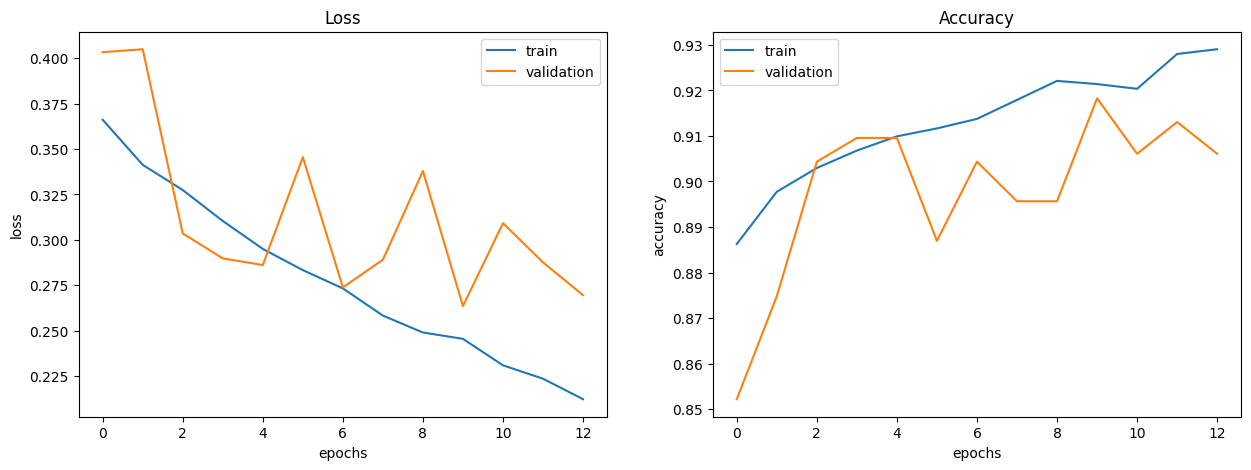

In [45]:
x_axis = logger.history['epoch']
train_loss = logger.history['train_loss']
val_loss = logger.history['val_loss']
train_acc = logger.history['train_accuracy']
val_acc = logger.history['val_accuracy']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(x_axis, train_loss, label='train')
plt.plot(x_axis, val_loss, label='validation')
plt.legend()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_acc, label='train')
plt.plot(x_axis, val_acc, label='validation')
plt.legend()
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title("Accuracy")
plt.show()

### Split 3

In [48]:
gc.collect()

9823

In [46]:
sql = ("""
  SELECT
    cancer_type,
    t.aliquot_barcode,
    fpkm_unstranded,
    Ensembl_gene_id
  FROM `{bq_project}.{bq_dataset}.{bq_table}` as t
  INNER JOIN (
    SELECT
      aliquot_barcode
    FROM `{bq_project}.{bq_dataset}.TCGA_sample_split_2`
  ) as s
  ON t.aliquot_barcode = s.aliquot_barcode
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()
df[['cancer_type', 'aliquot_barcode', 'Ensembl_gene_id']].nunique()

,0
cancer_type,33
aliquot_barcode,2875
Ensembl_gene_id,12555


Split 3:
* 2875 samples

In [47]:
data = df.pivot(index=['aliquot_barcode', 'cancer_type'], columns='Ensembl_gene_id', values='fpkm_unstranded')

# reset pivot table formatting
data.reset_index(inplace=True)
data.columns.name = None

y = data['cancer_type']
X = data.select_dtypes(include="number")

X_log = np.log10(X + 1)
y = pd.DataFrame(le.fit_transform(y), columns=['cancer_type'])

X_val_old = X_val
y_val_old = y_val


In [49]:
# 80% train + prev 20% val, 20% val
X_train, X_val, y_train, y_val = train_test_split(X_log, y, test_size=0.2, random_state=123)
# Use previous validation set as training data
X_train = pd.concat([X_train, X_val_old])
y_train = pd.concat([y_train, y_val_old])

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.flatten())
y_val_tensor = torch.tensor(y_val.values.flatten())

train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)

### Train from checkpoint

In [50]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=delta, patience=patience, mode="min")
checkpoint_callback = ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/',
                                          filename='best')
logger = CustomLogger()

trainer = L.Trainer(max_epochs=epochs,
                    check_val_every_n_epoch=val_epochs,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    logger=logger
                    )

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [51]:
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
model = NeuralNetwork.load_from_checkpoint('/content/checkpoints/best-v1.ckpt', weights_only=True, learning_rate=learning_rate)
trainer.fit(model, train_dataloader, val_dataloader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential         │  6.6 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.6 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

### Split 3 Plotting

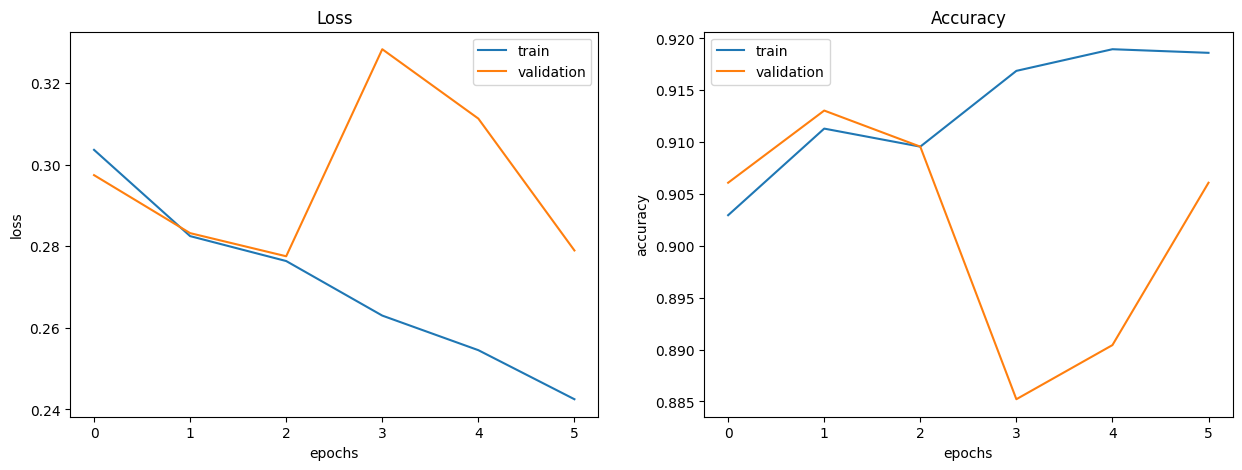

In [52]:
x_axis = logger.history['epoch']
train_loss = logger.history['train_loss']
val_loss = logger.history['val_loss']
train_acc = logger.history['train_accuracy']
val_acc = logger.history['val_accuracy']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(x_axis, train_loss, label='train')
plt.plot(x_axis, val_loss, label='validation')
plt.legend()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_acc, label='train')
plt.plot(x_axis, val_acc, label='validation')
plt.legend()
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title("Accuracy")
plt.show()

### Split 4

In [53]:
sql = ("""
  SELECT
    cancer_type,
    t.aliquot_barcode,
    fpkm_unstranded,
    Ensembl_gene_id
  FROM `{bq_project}.{bq_dataset}.{bq_table}` as t
  INNER JOIN (
    SELECT
      aliquot_barcode
    FROM `{bq_project}.{bq_dataset}.TCGA_sample_split_3`
  ) as s
  ON t.aliquot_barcode = s.aliquot_barcode
""").format(
    bq_project=bq_project,
    bq_dataset=bq_dataset,
    bq_table=bq_table
)

df = client.query(sql).result().to_dataframe()
df[['cancer_type', 'aliquot_barcode', 'Ensembl_gene_id']].nunique()

,0
cancer_type,33
aliquot_barcode,2875
Ensembl_gene_id,12555


Split 4:
* 2875 samples

In [54]:
data = df.pivot(index=['aliquot_barcode', 'cancer_type'], columns='Ensembl_gene_id', values='fpkm_unstranded')

# reset pivot table formatting
data.reset_index(inplace=True)
data.columns.name = None

y = data['cancer_type']
X = data.select_dtypes(include="number")

X_log = np.log10(X + 1)
y = pd.DataFrame(le.fit_transform(y), columns=['cancer_type'])


In [55]:
X_test_tensor = torch.tensor(X_log.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y.values.flatten())

test_data = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_data, batch_size=batch_size)


## Testing

In [56]:
# checkpoint_callback.best_model_path
trainer.test(dataloaders=test_dataloader, ckpt_path='best')

INFO: Restoring states from the checkpoint path at /content/checkpoints/best-v2.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best-v2.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/checkpoints/best-v2.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best-v2.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9109565019607544     │
│         test_loss         │    0.29123184084892273    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.29123184084892273, 'test_accuracy': 0.9109565019607544}]

### Other Evaluations

In [57]:
logits = trainer.predict(model, test_dataloader, ckpt_path='best')

INFO: Restoring states from the checkpoint path at /content/checkpoints/best-v2.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best-v2.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/checkpoints/best-v2.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best-v2.ckpt


Output()

In [58]:
y_true = y_test_tensor
y_pred = torch.argmax(torch.cat(logits), axis=1)
target_names = le.classes_

In [59]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred, labels=le.transform(target_names), target_names=target_names))

              precision    recall  f1-score   support

         ACC       0.78      0.95      0.86        19
        BLCA       0.87      0.95      0.91       108
        BRCA       1.00      0.99      1.00       308
        CESC       0.88      0.76      0.81        78
        CHOL       0.40      0.18      0.25        11
        COAD       0.75      1.00      0.86       131
        DLBC       0.92      1.00      0.96        12
        ESCA       0.71      0.30      0.42        50
         GBM       0.95      0.97      0.96        98
        HNSC       0.85      0.92      0.89       142
        KICH       0.59      0.86      0.70        22
        KIRC       0.99      0.88      0.93       153
        KIRP       0.89      0.93      0.91        81
        LAML       1.00      1.00      1.00        38
         LGG       0.98      0.97      0.98       133
        LIHC       0.93      0.95      0.94       106
        LUAD       0.93      0.85      0.89       150
        LUSC       0.77    

In [60]:
confusion_matrix = confusion_matrix(y_true, y_pred, labels=le.transform(target_names))
print(confusion_matrix)

[[ 18   0   0 ...   0   0   0]
 [  0 103   0 ...   0   0   0]
 [  0   1 306 ...   0   0   0]
 ...
 [  1   0   0 ... 141   2   0]
 [  0   0   0 ...   6   7   0]
 [  0   0   0 ...   0   0  20]]


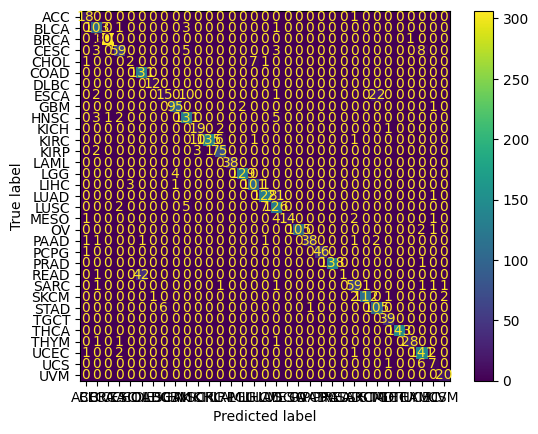

In [61]:
disp = ConfusionMatrixDisplay(confusion_matrix, display_labels=target_names)
disp.plot()